<a href="https://colab.research.google.com/github/comparativechrono/nugap/blob/main/tutorial_nugap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `nugap` — a hands-on tutorial
**Detecting condition-specific changes in *dynamics* with the Vinnicombe ν-gap**

`nugap` answers a specific question about two-condition time-course data: *which variables, or which relationships between them, change their **dynamical behaviour** between conditions* — wild type vs mutant, untreated vs treated, and so on. It is built around the **Vinnicombe ν-gap**, a bounded (0–1) distance between linear dynamical models from robust control theory: two systems close in ν-gap behave the same way under feedback.

In this notebook we will:
1. compute the ν-gap between two systems and see what it measures;
2. fit dynamical models to time-series data;
3. run the headline workflow — comparing a whole interaction network between two conditions, with replicate-based significance;
4. cover the per-variable comparison, the main options, and good practice.

It runs on Google Colab — just execute the cells top to bottom.

In [1]:
# Install from PyPI (skips quickly if already present). On Colab this is all you need.
%pip install -q nugap

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi

import nugap
from nugap import tf, nu_gap, chordal_distance, fit_first_order, dc_gain
from nugap import compare_network, compare_conditions
print("nugap version:", nugap.__version__)

nugap version: 0.2.0


## 1. The ν-gap between two systems

A linear system is built with `tf(numerator, denominator)`, coefficients in **descending powers of `s`** — so `tf([1],[1,1])` is $1/(s+1)$. The metric `nu_gap(P1, P2)` returns a number in $[0,1]$: **0** means identical, **1** means maximally different (as seen by any stabilising feedback controller).

In [3]:
P1 = tf([1.0], [1.0, 1.0])   # 1/(s+1)
P2 = tf([1.0], [1.0, 3.0])   # 1/(s+3): same shape, faster pole

print("nu-gap(P1, P2) =", round(nu_gap(P1, P2), 4))
print("nu-gap(P1, P1) =", round(nu_gap(P1, P1), 6), "(identical -> 0)")

nu-gap(P1, P2) = 0.4472
nu-gap(P1, P1) = 0.0 (identical -> 0)


### What the number means

The ν-gap is the **worst-case chordal distance** between the two frequency responses, over all frequencies (subject to a topological winding condition). The chordal distance is a bounded distance on the Riemann sphere, so it stays meaningful even when gains differ wildly. The plot below shows that pointwise distance; the ν-gap is the peak of the curve.

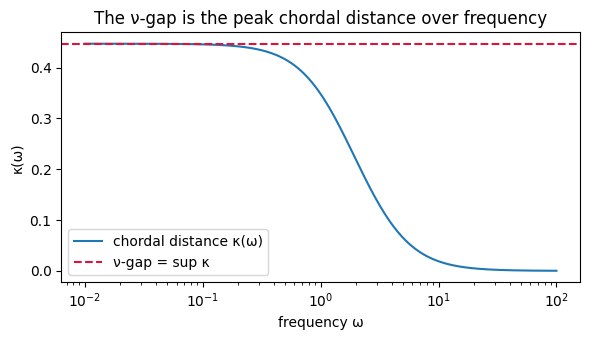

In [4]:
w = np.logspace(-2, 2, 400)
kappa = chordal_distance(P1.freqresp(1j*w), P2.freqresp(1j*w))

plt.figure(figsize=(6, 3.5))
plt.semilogx(w, kappa, label="chordal distance κ(ω)")
plt.axhline(nu_gap(P1, P2), ls="--", color="crimson", label="ν-gap = sup κ")
plt.xlabel("frequency ω"); plt.ylabel("κ(ω)")
plt.title("The ν-gap is the peak chordal distance over frequency")
plt.legend(); plt.tight_layout(); plt.show()

### Options for oscillatory data

For signals concentrated near a particular frequency — circadian time-courses, say — the model fit is dominated by that band, and it makes sense to measure the gap only there. Pass `band=(ω_low, ω_high)` in angular frequency (for periods $P_\max..P_\min$ use $2\pi/P_\max$ and $2\pi/P_\min$), and optionally switch off the winding test with `check_winding=False`. The default is the full-spectrum metric with the winding condition.

In [5]:
broadband = nu_gap(P1, P2)
band      = nu_gap(P1, P2, band=(2*pi/36, 2*pi/16), check_winding=False)  # ~16–36 h periods
print(f"broadband ν-gap    = {broadband:.3f}")
print(f"band-limited ν-gap = {band:.3f}")

broadband ν-gap    = 0.447
band-limited ν-gap = 0.443


## 2. Fitting dynamical models from time series

Usually you don't start with transfer functions — you have sampled trajectories. `fit_first_order(t, y, u)` fits a first-order input→output model and returns `(model, R²)`, where R² comes from **simulating** the model from the input, so a high R² means the input genuinely drives the output. `dc_gain(model)` is the static input→output gain. Below, one input drives an output with a fast response in condition A and a slow one in B; the ν-gap between the fitted models quantifies that change.

In [6]:
t = np.arange(0, 72, 2.0)            # 36 time points, 2 h apart
rng = np.random.default_rng(7)

def first_order(u, tau, dt=2.0):     # simulate a first-order response to u
    y = np.zeros_like(u); a = np.exp(-dt/tau)
    for k in range(1, len(u)):
        y[k] = a*y[k-1] + (1 - a)*u[k-1]
    return y

u  = np.sin(2*pi*t/24)               # a circadian-period driver
yA = first_order(u, tau=4.0)  + 0.02*rng.standard_normal(len(t))
yB = first_order(u, tau=12.0) + 0.02*rng.standard_normal(len(t))   # slower in B

mA, r2A = fit_first_order(t, yA, u)
mB, r2B = fit_first_order(t, yB, u)
print(f"fit R²:   A = {r2A:.3f},  B = {r2B:.3f}")
print(f"DC gain:  A = {dc_gain(mA):.2f},  B = {dc_gain(mB):.2f}")
print(f"ν-gap between the two conditions = {nu_gap(mA, mB):.3f}")

fit R²:   A = 0.999,  B = 0.993
DC gain:  A = 0.99,  B = 1.02
ν-gap between the two conditions = 0.349


## 3. The main workflow: comparing an interaction network between conditions

The headline use case is system-scale: many variables measured under two conditions with replicates, asking *which input→output relationships are rewired?* `compare_network` fits a first-order model to every ordered pair of variables in each condition, computes the ν-gap between conditions, and uses the **replicate spread** as an empirical null with Benjamini–Hochberg FDR control.

We simulate a small, transparent example: **two modules**, each a driver and two targets. Module 1 is unchanged between conditions; module 2 is **perturbed** — its targets respond much more slowly in condition B. A background variable is related to nothing.

In [7]:
rng = np.random.default_rng(0)       # reseed for a reproducible network example

def reps(gen, nrep=4, noise=0.06):   # nrep noisy replicates of a signal
    return np.stack([gen() + noise*rng.standard_normal(len(t)) for _ in range(nrep)])

d1 = np.sin(2*pi*t/24)               # driver of module 1
d2 = np.sin(2*pi*t/18 + 0.7)         # an independent driver of module 2

A, B = {}, {}                        # var -> (replicates x time) under each condition
A['D1']  = reps(lambda: d1);                    B['D1']  = reps(lambda: d1)
A['T1a'] = reps(lambda: first_order(d1, 4.0));  B['T1a'] = reps(lambda: first_order(d1, 4.0))   # unchanged
A['T1b'] = reps(lambda: first_order(d1, 6.0));  B['T1b'] = reps(lambda: first_order(d1, 6.0))   # unchanged
A['D2']  = reps(lambda: d2);                    B['D2']  = reps(lambda: d2)
A['T2a'] = reps(lambda: first_order(d2, 4.0));  B['T2a'] = reps(lambda: first_order(d2, 14.0))  # CHANGED
A['T2b'] = reps(lambda: first_order(d2, 3.0));  B['T2b'] = reps(lambda: first_order(d2, 16.0))  # CHANGED
A['BG']  = reps(lambda: rng.standard_normal(len(t)))
B['BG']  = reps(lambda: rng.standard_normal(len(t)))
print("variables:", list(A))

variables: ['D1', 'T1a', 'T1b', 'D2', 'T2a', 'T2b', 'BG']


In [8]:
edges = compare_network(A, B, t, order=1, min_r2=0.5, gate='either')

cols = ['source', 'target', 'nu_gap', 'within_median', 'max_r2', 'q_global']
print("Edges that passed the fit-quality gate (sorted by significance):")
print(edges[cols].round(3).to_string(index=False))

Edges that passed the fit-quality gate (sorted by significance):
source target  nu_gap  within_median  max_r2  q_global
   T2a    T2b   1.000          0.168   0.648     0.031
   T2b     D2   0.537          0.016   0.813     0.031
   T2b    T2a   0.988          0.363   0.858     0.031
    D2    T2a   0.381          0.053   0.979     0.062
    D2    T2b   0.461          0.036   0.988     0.062
   T2a     D2   0.418          0.025   0.894     0.062
   T1a    T1b   0.171          0.275   0.916     0.278
    D1    T1b   0.030          0.032   0.973     0.638
    D1    T1a   0.014          0.008   0.982     0.804


### Reading the result

Each row is a directed edge *source → target*. `nu_gap` is the between-condition change in that relationship, `within_median` is the replicate noise floor for the edge, and `q_global` is the FDR-adjusted significance. Edges with **`q_global < 0.1`** are the rewired relationships.

All the **module-2** edges (D2, T2a, T2b) are flagged, while the unchanged **module-1** edges (D1, T1a, T1b) sit near the noise floor and are not — and the background variable and cross-module pairs never even passed the gate, because no first-order relationship fits them. The comparison has localised the perturbation to module 2.

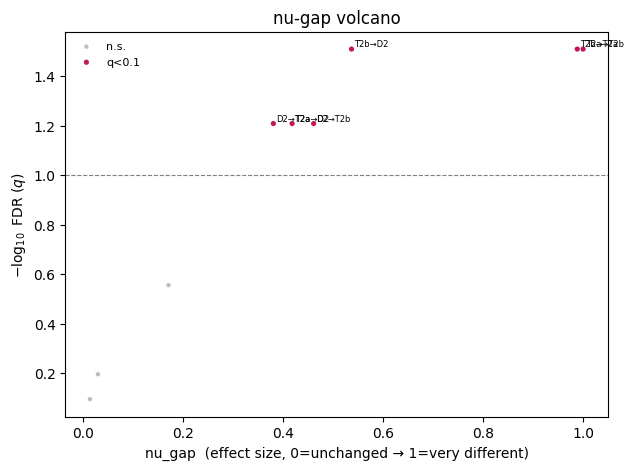

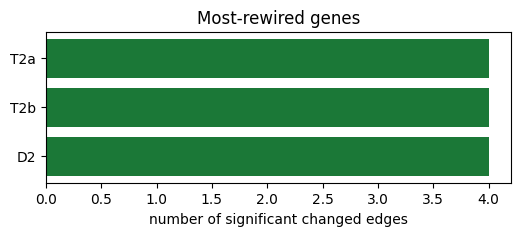

In [9]:
from nugap.viz import volcano, hub_barplot

volcano(edges); plt.show()
hub_barplot(edges); plt.show()

## 4. Per-variable comparison

When you have a known stimulus and want to ask *which variables change how they respond to it*, `compare_conditions` fits one model per variable (optionally with a shared input `u`) and compares conditions, keeping a `reliable` flag from the fit quality. Here we use module-2's driver as the input: only the variables that actually respond to it are reliable, and among those the perturbed targets show the larger ν-gap.

In [10]:
yA = {k: A[k].mean(0) for k in A}    # average the replicates
yB = {k: B[k].mean(0) for k in B}
per_var = compare_conditions(yA, yB, t, u_A=A['D2'].mean(0), u_B=B['D2'].mean(0),
                             orders=range(1, 3), min_r2=0.5)
print(per_var[['variable', 'nu_gap', 'r2_A', 'r2_B', 'reliable']].round(3).to_string(index=False))

variable  nu_gap   r2_A   r2_B  reliable
      BG   0.503 -0.015 -0.022     False
     T2b   0.443  0.568  0.501      True
     T2a   0.355  0.564  0.517      True
     T1a   0.103 -0.019 -0.015     False
      D1   0.032 -0.005 -0.007     False
     T1b   0.015 -0.026 -0.026     False
      D2   0.007  0.479  0.481     False


## 5. Options and good practice

- **Fit-quality gate** (`min_r2`, default 0.5) and **gate rule** (`gate='either' | 'both' | 'mean'`): `either` catches relationships that appear or disappear between conditions; `both` is the conservative choice (present in both). Only gated-in edges are tested, which keeps the null meaningful.
- **Replicates** drive the empirical null and the per-edge noise floor (`within_median`). With ≥2 replicates per condition you get calibrated significance; with one you still get effect sizes (`nu_gap`) but no within-condition floor.
- **Band-limited metric** (`band=`, `check_winding=False`) for oscillatory data, as in §1.
- **DC-gain floor** (`fit_first_order(..., min_dc_gain=0.1)`) rejects models where the input barely drives the output.
- **Model order**: with few time points keep `order=1`; higher orders need more samples and can overfit.

**Caveats.** Models are SISO, so an edge is a pairwise input→output relationship, not proven causation; and the metric is computed on mean-centred trajectories, so it reflects changes in the *relationship* (timescale, gain, phase), not in absolute level.

## Where to go next

- **API and mathematics:** the package documentation and the accompanying methods paper.
- **Correctness:** the package ships a validation suite (`validation/`), including closed-form checks, the robust-stability theorem, and a cross-check against MATLAB's `gapmetric`.
- **Cite:** Hearn (2025), *nugap* (see the repository / Zenodo record). https://doi.org/10.5281/zenodo.20693443